<a href="https://colab.research.google.com/github/ManideepLadi/cs6910_assignment3/blob/manideep/RNN4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dakshina Dataset from google


In [44]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
from tensorflow.keras.utils import plot_model
from copy import copy


In [ ]:
!wget https://storage.googleapis.com/gresearch/dakshina/dakshina_dataset_v1.0.tar

In [3]:
!tar -xvf '/content/dakshina_dataset_v1.0.tar'

dakshina_dataset_v1.0/bn/
dakshina_dataset_v1.0/bn/lexicons/
dakshina_dataset_v1.0/bn/lexicons/bn.translit.sampled.test.tsv
dakshina_dataset_v1.0/bn/lexicons/bn.translit.sampled.train.tsv
dakshina_dataset_v1.0/bn/lexicons/bn.translit.sampled.dev.tsv
dakshina_dataset_v1.0/bn/native_script_wikipedia/
dakshina_dataset_v1.0/bn/native_script_wikipedia/bn.wiki-filt.valid.text.shuf.txt.gz
dakshina_dataset_v1.0/bn/native_script_wikipedia/bn.wiki-full.info.sorted.tsv.gz
dakshina_dataset_v1.0/bn/native_script_wikipedia/bn.wiki-filt.train.info.sorted.tsv.gz
dakshina_dataset_v1.0/bn/native_script_wikipedia/bn.wiki-filt.train.text.sorted.tsv.gz
dakshina_dataset_v1.0/bn/native_script_wikipedia/bn.wiki-filt.train.text.shuf.txt.gz
dakshina_dataset_v1.0/bn/native_script_wikipedia/bn.wiki-full.nonblock.sections.tsv.gz
dakshina_dataset_v1.0/bn/native_script_wikipedia/bn.wiki-full.omit_pages.txt.gz
dakshina_dataset_v1.0/bn/native_script_wikipedia/bn.wiki-full.text.sorted.tsv.gz
dakshina_dataset_v1.0/bn/na

Preprocess data

In [4]:

# load dataset
train_filename = 'dakshina_dataset_v1.0/te/lexicons/te.translit.sampled.train.tsv'
validation_filename = 'dakshina_dataset_v1.0/te/lexicons/te.translit.sampled.dev.tsv'
# doc = load_doc(filename)
# # split into english-german pairs
# pairs = to_pairs(doc)

In [5]:
# Vectorize the data.
input_texts = []
target_texts = []
input_characters = set()
target_characters = set()
inputdata=[]
with open(train_filename, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")
for line in lines[: len(lines) - 1]:
    inputdata.append(line)
random.shuffle(inputdata)
for line in inputdata:
    target_text,input_text, attestation = line.split("\t")
    # We use "tab" as the "start sequence" character
    # for the targets, and "\n" as "end sequence" character.
    target_text = "\t" + target_text + "\n"
    for i in range(int(attestation)):
      input_texts.append(input_text)
      target_texts.append(target_text)
    for char in input_text:
        if char not in input_characters:
            input_characters.add(char)
    for char in target_text:
        if char not in target_characters:
            target_characters.add(char)

input_characters = sorted(list(input_characters))
target_characters = sorted(list(target_characters))
num_encoder_tokens = len(input_characters)
num_decoder_tokens = len(target_characters)
max_encoder_seq_length = max([len(txt) for txt in input_texts])
max_decoder_seq_length = max([len(txt) for txt in target_texts])

print("Number of samples:", len(input_texts))
print("Number of unique input tokens:", num_encoder_tokens)
print("Number of unique output tokens:", num_decoder_tokens)
print("Max sequence length for inputs:", max_encoder_seq_length)
print("Max sequence length for outputs:", max_decoder_seq_length)

Number of samples: 84680
Number of unique input tokens: 26
Number of unique output tokens: 65
Max sequence length for inputs: 25
Max sequence length for outputs: 22


In [6]:
input_texts[10]

'jaan'

In [7]:
# Vectorize the data.
validation_input_texts = []
validation_target_texts = []

with open(validation_filename, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")
for line in lines[: len(lines) - 1]:
    validation_target_text,validation_input_text, attestation = line.split("\t")
    # We use "tab" as the "start sequence" character
    # for the targets, and "\n" as "end sequence" character.
    validation_target_text = "\t" + validation_target_text + "\n"
    for i in range(int(attestation)):
      validation_input_texts.append(validation_input_text)
      validation_target_texts.append(validation_target_text)
    for char in validation_input_text:
        if char not in input_characters:
            input_characters.add(char)
    for char in validation_target_text:
        if char not in target_characters:
            target_characters.add(char)

input_characters = sorted(list(input_characters))
target_characters = sorted(list(target_characters))
validation_num_encoder_tokens = len(input_characters)
validation_num_decoder_tokens = len(target_characters)
validation_max_encoder_seq_length = max([len(txt) for txt in validation_input_texts])
validation_max_decoder_seq_length = max([len(txt) for txt in validation_target_texts])

print("Number of validation samples:", len(validation_input_texts))
print("Number of unique input tokens:", validation_num_encoder_tokens)
print("Number of unique output tokens:", validation_num_decoder_tokens)
print("validation Max sequence length for inputs:", validation_max_encoder_seq_length)
print("validation Max sequence length for outputs:", validation_max_decoder_seq_length)

Number of validation samples: 8393
Number of unique input tokens: 26
Number of unique output tokens: 65
validation Max sequence length for inputs: 21
validation Max sequence length for outputs: 21


In [8]:
input_token_index = dict([(char, i) for i, char in enumerate(input_characters)])
target_token_index = dict([(char, i) for i, char in enumerate(target_characters)])

reverse_input_char_index = dict((i, char) for char, i in input_token_index.items())
reverse_target_char_index = dict((i, char) for char, i in target_token_index.items())

encoder_input_data = np.zeros(
    (len(input_texts), max_encoder_seq_length, num_encoder_tokens), dtype="float32"
)
validation_encoder_input_data=np.zeros(
    (len(validation_input_texts), max_encoder_seq_length, num_encoder_tokens), dtype="float32"
)
decoder_input_data = np.zeros(
    (len(input_texts), max_encoder_seq_length, num_decoder_tokens), dtype="float32"
)
validation_decoder_input_data =np.zeros(
    (len(validation_input_texts), max_encoder_seq_length, num_decoder_tokens), dtype="float32"
)
decoder_target_data = np.zeros(
    (len(input_texts), max_encoder_seq_length, num_decoder_tokens), dtype="float32"
)
validation_decoder_target_data = np.zeros(
    (len(validation_input_texts), max_encoder_seq_length, num_decoder_tokens), dtype="float32"
)

for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
    for t, char in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[char]] = 1.0
    for t, char in enumerate(target_text):
        # decoder_target_data is ahead of decoder_input_data by one timestep
        decoder_input_data[i, t, target_token_index[char]] = 1.0
        if t > 0:
            # decoder_target_data will be ahead by one timestep
            # and will not include the start character.
            decoder_target_data[i, t - 1, target_token_index[char]] = 1.0
# for validation data
for i, (validation_input_text, validation_target_text) in enumerate(zip(validation_input_texts, validation_target_texts)):
    for t, char in enumerate(validation_input_text):
        validation_encoder_input_data[i, t, input_token_index[char]] = 1.0
    for t, char in enumerate(validation_target_text):
        # decoder_target_data is ahead of decoder_input_data by one timestep
        validation_decoder_input_data[i, t, target_token_index[char]] = 1.0
        if t > 0:
            # decoder_target_data will be ahead by one timestep
            # and will not include the start character.
            validation_decoder_target_data[i, t - 1, target_token_index[char]] = 1.0

In [ ]:
validation_input_texts[100]

'agreeculture'

In [ ]:
validation_encoder_input_data[1].shape

(25, 26)

In [ ]:
validation_decoder_input_data[0].shape

(25, 65)

In [ ]:
decoder_target_data[0].shape

(25, 65)

In [10]:
class RNN_Model:

  def __init__(self,no_of_encoder_layers,no_of_decoder_layers,latent_dimension,dropout,recurrent_dropout,cell_type):

    self.no_of_encoder_layers = no_of_encoder_layers
    self.no_of_decoder_layers = no_of_decoder_layers
    self.latent_dimension = latent_dimension
    self.dropout = dropout
    self.recurrent_dropout=recurrent_dropout
    self.cell_type=cell_type
    self.model = None
    self.encoder_inputs= None
    self.encoder_states = None
    self.decoder_inputs = None
    self.output_layers = []
    self.decoder_dense = None


  def printModelParameters(self):
    print(self.no_of_encoder_layers)
    print(self.no_of_decoder_layers)
    print(self.latent_dimension)
    print(self.dropout)
    print(self.model.summary())

  def BUILD_MODEL(self,num_encoder_tokens,num_decoder_tokens):
    self.encoder_inputs = keras.Input(shape=(None, num_encoder_tokens))

    outputs = self.encoder_inputs
    self.encoder_states = []
    for j in range(self.no_of_encoder_layers)[::-1]:
      if self.cell_type == "LSTM":
        outputs, h , c = keras.layers.LSTM(self.latent_dimension, return_state=True, return_sequences=bool(j),dropout=self.dropout,recurrent_dropout=self.recurrent_dropout)(outputs)
        self.encoder_states += [h,c]
      elif self.cell_type == "GRU" :
        outputs, h = keras.layers.GRU(self.latent_dimension, return_state=True, return_sequences=bool(j),dropout=self.dropout,recurrent_dropout=self.recurrent_dropout)(outputs)
        self.encoder_states += [h]
      elif self.cell_type == "RNN" :
        outputs, h = keras.layers.SimpleRNN(self.latent_dimension, return_state=True, return_sequences=bool(j),dropout=self.dropout,recurrent_dropout=self.recurrent_dropout)(outputs)
        self.encoder_states += [h]

    self.decoder_inputs = keras.Input(shape=(None, num_decoder_tokens))

    outputs = self.decoder_inputs
    for j in range(self.no_of_decoder_layers):
        if self.cell_type == "LSTM":
          self.output_layers.append(
              keras.layers.GRU(self.latent_dimension, return_sequences=True, return_state=True,dropout=self.dropout,recurrent_dropout=self.recurrent_dropout)
          )
          outputs, dh, dc = self.output_layers[-1](outputs, initial_state=[self.encoder_states[-2],self.encoder_states[-1]])
        elif self.cell_type == "GRU" : 
          self.output_layers.append(
              keras.layers.GRU(self.latent_dimension, return_sequences=True, return_state=True,dropout=self.dropout,recurrent_dropout=self.recurrent_dropout)
          )
          outputs, dh = self.output_layers[-1](outputs, initial_state=self.encoder_states[-1])
        elif self.cell_type == "RNN" : 
          self.output_layers.append(
              keras.layers.SimpleRNN(self.latent_dimension, return_sequences=True, return_state=True,dropout=self.dropout,recurrent_dropout=self.recurrent_dropout)
          )
          outputs, dh = self.output_layers[-1](outputs, initial_state=self.encoder_states[-1])

 
    self.decoder_dense = keras.layers.Dense(num_decoder_tokens, activation='softmax')
    decoder_outputs = self.decoder_dense(outputs)
    # Define the model that will turn
    # `encoder_input_data` & `decoder_input_data` into `decoder_target_data`
    self.model = keras.Model([self.encoder_inputs, self.decoder_inputs], decoder_outputs)
    self.model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy']) 
    return 


  #Fit model using the train datagenerator and returns fitted model..
  def FIT_RNN(self , encoder_input_data,decoder_input_data ,decoder_target_data,epochs ,batch_size,validation_encoder_input_data,validation_decoder_input_data,validation_decoder_target_data):
    self.model.fit(
        [encoder_input_data, decoder_input_data],
        decoder_target_data,
        batch_size=batch_size,
        epochs=epochs,
        shuffle=True,
        validation_data=([validation_encoder_input_data, validation_decoder_input_data],validation_decoder_target_data))
        # ,
        # callbacks = [WandbCallback(monitor='val_accuracy',
        #                                             save_model = True)],verbose=1)
    return
  def load_model(self):
    encoder_model = keras.Model(self.encoder_inputs, self.encoder_states)
    d_outputs = self.decoder_inputs
    decoder_states_inputs = []
    decoder_states = []
    for j in range(self.no_of_decoder_layers):
        if self.cell_type =="LSTM":
          current_state_inputs = [keras.Input(shape=(self.latent_dimension,)) for _ in range(2)]
        else :
          current_state_inputs = [keras.Input(shape=(self.latent_dimension,))]

        temp = self.output_layers[j](d_outputs, initial_state=current_state_inputs)

        d_outputs, cur_states = temp[0], temp[1:]

        decoder_states += cur_states
        decoder_states_inputs += current_state_inputs

    decoder_outputs = self.decoder_dense(d_outputs)
    decoder_model = keras.Model(
        [self.decoder_inputs] + decoder_states_inputs,
        [decoder_outputs] + decoder_states)
    return encoder_model,decoder_model


In [ ]:
!pip install wandb -qqq
import wandb
wandb.login()

     |████████████████████████████████| 1.8MB 8.0MB/s 
     |████████████████████████████████| 102kB 13.3MB/s 
     |████████████████████████████████| 163kB 47.4MB/s 
     |████████████████████████████████| 133kB 53.7MB/s 
     |████████████████████████████████| 71kB 10.1MB/s 


<IPython.core.display.Javascript object>

wandb: You can find your API key in your browser here: https://wandb.ai/authorize


wandb: Paste an API key from your profile and hit enter: ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [ ]:
import wandb
from wandb.keras import WandbCallback

In [ ]:
sweep_config = {
  'name': 'RNN',
  'method': 'grid',
  'metric': {
      'name': 'accuracy',
      'goal': 'maximize'   
    },
  'parameters': {
        'encoder_layers':{
            'values':[1,2,3]
        },
        'decoder_layers':{
            'values':[1,2,3]
        },
        'hidden_layer_size':{
            'values':[16, 32, 64, 256]
        },
        'cell_type':{
            'values':['RNN', 'GRU', 'LSTM']
        },
        'dropout':{
            'values':[0.3,0.2,0.0]
        },
        'recurrent_dropout':{
            'values':[0.3,0.2,0.0]
        }

    }
}

sweep_id = wandb.sweep(sweep_config, project='RNN', entity='manideepladi')

Create sweep with ID: l39l854n
Sweep URL: https://wandb.ai/manideepladi/RNN/sweeps/l39l854n


In [ ]:
def train():
  run = wandb.init()
  configuration=run.config

  rnn = RNN_Model(no_of_encoder_layers=configuration.encoder_layers,no_of_decoder_layers=configuration.decoder_layers,
                  latent_dimension=configuration.hidden_layer_size,dropout=configuration.dropout,recurrent_dropout=configuration.recurrent_dropout,cell_type=configuration.cell_type)
  rnn.BUILD_MODEL(num_encoder_tokens,num_decoder_tokens)
  rnn.FIT_RNN( encoder_input_data,decoder_input_data,  decoder_target_data,10,64,
    validation_encoder_input_data , validation_decoder_input_data, validation_decoder_target_data)
sweep_id="j7uwtz9w"
wandb.agent(sweep_id=sweep_id, function=train)

wandb: Agent Starting Run: 6r1to8nj with config:
wandb: 	cell_type: RNN
wandb: 	decoder_layers: 1
wandb: 	dropout: 0.3
wandb: 	encoder_layers: 1
wandb: 	hidden_layer_size: 256
wandb: 	recurrent_dropout: 0.2


Epoch 1/10
1324/1324 [==============================] - 75s 53ms/step - loss: 1.1684 - accuracy: 0.0600 - val_loss: 1.0468 - val_accuracy: 0.0698
Epoch 2/10
1324/1324 [==============================] - 70s 53ms/step - loss: 1.1096 - accuracy: 0.0524 - val_loss: 1.0334 - val_accuracy: 0.0722
Epoch 3/10
1324/1324 [==============================] - 71s 53ms/step - loss: 1.0995 - accuracy: 0.0569 - val_loss: 1.0171 - val_accuracy: 0.0494
Epoch 4/10
1324/1324 [==============================] - 71s 54ms/step - loss: 1.0934 - accuracy: 0.0525 - val_loss: 1.0121 - val_accuracy: 0.0497
Epoch 5/10
1324/1324 [==============================] - 68s 52ms/step - loss: 1.0846 - accuracy: 0.0598 - val_loss: 1.0067 - val_accuracy: 0.0534
Epoch 6/10
1324/1324 [==============================] - 68s 51ms/step - loss: 1.0820 - accuracy: 0.0631 - val_loss: 0.9958 - val_accuracy: 0.0616
Epoch 7/10
1324/1324 [==============================] - 69s 52ms/step - loss: 1.0693 - accuracy: 0.0711 - val_loss: 0.9854 -

epoch,9
loss,1.05062
accuracy,0.0766
val_loss,0.96628
val_accuracy,0.08199
_runtime,713
_timestamp,1620584964
_step,9
best_val_accuracy,0.08199
best_epoch,9


epoch,▁▂▃▃▄▅▆▆▇█
loss,█▅▅▄▄▃▂▂▁▁
accuracy,▄▁▁▂▃▅▆██▇
val_loss,█▇▅▅▅▄▃▃▁▁
val_accuracy,▅▆▁▁▂▄▅███
_runtime,▁▂▃▃▄▅▆▆▇█
_timestamp,▁▂▃▃▄▅▆▆▇█
_step,▁▂▃▃▄▅▆▆▇█


wandb: Agent Starting Run: auaizqn1 with config:
wandb: 	cell_type: RNN
wandb: 	decoder_layers: 1
wandb: 	dropout: 0.3
wandb: 	encoder_layers: 1
wandb: 	hidden_layer_size: 64
wandb: 	recurrent_dropout: 0.2


Epoch 1/10
1324/1324 [==============================] - 67s 49ms/step - loss: 1.2339 - accuracy: 0.0537 - val_loss: 1.0881 - val_accuracy: 0.0670
Epoch 2/10
1324/1324 [==============================] - 65s 49ms/step - loss: 1.1575 - accuracy: 0.0662 - val_loss: 1.0690 - val_accuracy: 0.0480
Epoch 3/10
1324/1324 [==============================] - 64s 49ms/step - loss: 1.1387 - accuracy: 0.0472 - val_loss: 1.0555 - val_accuracy: 0.0475
Epoch 4/10
1324/1324 [==============================] - 65s 49ms/step - loss: 1.1251 - accuracy: 0.0557 - val_loss: 1.0457 - val_accuracy: 0.0561
Epoch 5/10
1324/1324 [==============================] - 65s 49ms/step - loss: 1.1131 - accuracy: 0.0669 - val_loss: 1.0351 - val_accuracy: 0.0672
Epoch 6/10
1324/1324 [==============================] - 64s 48ms/step - loss: 1.1058 - accuracy: 0.0680 - val_loss: 1.0295 - val_accuracy: 0.0742
Epoch 7/10
1324/1324 [==============================] - 63s 48ms/step - loss: 1.0952 - accuracy: 0.0683 - val_loss: 1.0221 -

epoch,9
loss,1.07987
accuracy,0.07145
val_loss,0.99833
val_accuracy,0.07987
_runtime,639
_timestamp,1620585608
_step,9
best_val_accuracy,0.08125
best_epoch,7


epoch,▁▂▃▃▄▅▆▆▇█
loss,█▅▄▄▃▂▂▂▁▁
accuracy,▅▅▁▅▇▇▇▇▇█
val_loss,█▇▅▅▄▃▃▂▂▁
val_accuracy,▅▁▁▃▅▇▇███
_runtime,▁▂▃▃▄▅▆▇▇█
_timestamp,▁▂▃▃▄▅▆▇▇█
_step,▁▂▃▃▄▅▆▆▇█


wandb: Agent Starting Run: xwbz4amp with config:
wandb: 	cell_type: RNN
wandb: 	decoder_layers: 1
wandb: 	dropout: 0.3
wandb: 	encoder_layers: 1
wandb: 	hidden_layer_size: 64
wandb: 	recurrent_dropout: 0


Epoch 1/10
 335/1324 [======>.......................] - ETA: 34s - loss: 1.2982 - accuracy: 0.0586

In [ ]:
rnn = RNN_Model(2,2,512,0.3,0,"GRU")
rnn.BUILD_MODEL(num_encoder_tokens,num_decoder_tokens)

In [ ]:
rnn.model.summary()

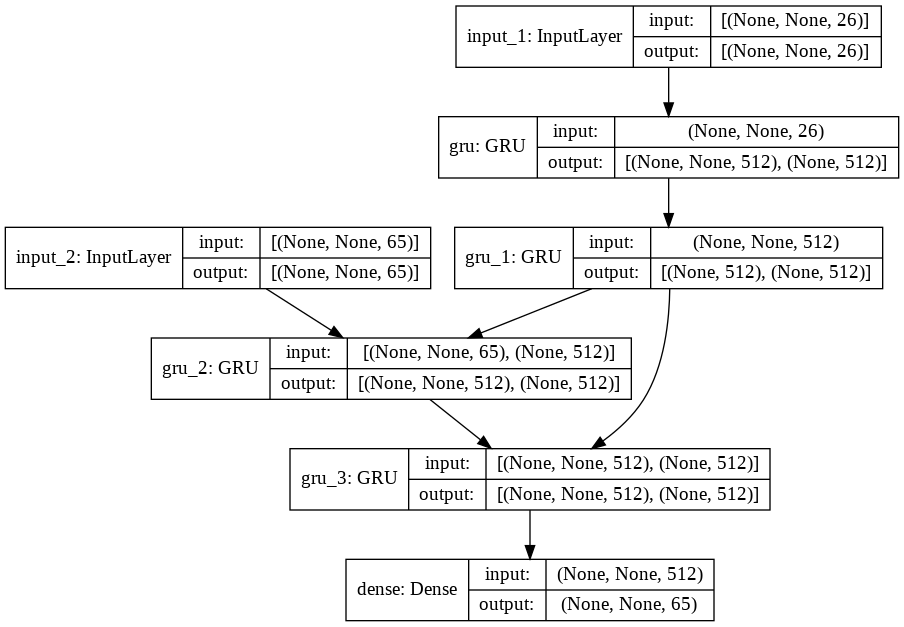

In [13]:
plot_model(rnn.model, show_shapes=True)

In [ ]:
rnn.FIT_RNN( encoder_input_data,decoder_input_data,  decoder_target_data,10,32,
    validation_encoder_input_data,
    validation_decoder_input_data,validation_decoder_target_data)

Epoch 1/10
2647/2647 [==============================] - 54s 20ms/step - loss: 0.4778 - accuracy: 0.2211 - val_loss: 0.3676 - val_accuracy: 0.2296
Epoch 2/10
  88/2647 [..............................] - ETA: 49s - loss: 0.4829 - accuracy: 0.2236

In [ ]:
# rnn.FIT_RNN( encoder_input_data,decoder_input_data,  decoder_target_data,20,32,
#             validation_encoder_input_data , validation_decoder_input_data, validation_decoder_target_data)

In [15]:
yPred=rnn.model.predict([encoder_input_data,decoder_input_data])
ytrue = decoder_target_data
print(ytrue.shape)
countCharacters = 0
for i in range(yPred.shape[0]):
  for j in range(yPred.shape[1]):
    if np.argmax(yPred[i,j,:])== np.argmax(ytrue[i,j,:]) :
      countCharacters=countCharacters+1
print(countCharacters)



(84680, 25, 65)
508406


In [97]:
encoder_model,decoder_model= rnn.load_model()
input_seq=encoder_input_data[100: 100 + 1]

def decode_translate(seq):
  decoded_sentence = [] 
  for x in seq:
    sampled_char = reverse_target_char_index[x]
    decoded_sentence.append(sampled_char)
  return "".join(decoded_sentence)
def decode_sequence(input_seq, encoder_model, decoder_model):
    b=2
    # result holders
    final_results = []
    final_probs = []
    # Encode the input as state vectors.
    states_value = encoder_model.predict(input_seq)

    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    # Populate the first character of target sequence with the start character.
    target_seq[0, 0, target_token_index['\t']] = 1.

    to_split = decoder_model.predict([target_seq] + states_value)
     
    output_tokens, states_value = to_split[0], to_split[1:]
        # Sample a token
    seq_indices = np.argsort(output_tokens[0, -1,:])[-b:][::-1]
    # top b probs
    seq_probs = np.log(output_tokens[0,-1,seq_indices])
    sum_probs = copy(list(seq_probs))
    seq_states = [[states_value] for x in range(b)]

    # consider each elemnt in lists as a separate list (to keep sequences of predictions)
    seq_indices = [[x] for x in seq_indices]
    seq_probs = [[x] for x in seq_probs]

     # list of alive predictions sequences (not faced "eos" token)
    alive_seqs = b

    while alive_seqs > 0:
      # temp lists
      temp_seqs = []
      temp_probs = []
      temp_sum_probs = []
      temp_states = []
      for i in range(len(seq_indices)):
        # current seq of indices and related probs
        seq = copy(seq_indices[i])
        probs = copy(seq_probs[i])
        states = copy(seq_states[i]) # list object [h,c]

        # Generate empty target sequence of length 1.
        target_seq = np.zeros((1, 1, num_decoder_tokens))
        # consider last word in current sequence
        target_seq[ 0 , 0 ,target_token_index[reverse_target_char_index[seq[-1]]] ] = 1
        # predict
        dec_outputs, h, c = decoder_model.predict([target_seq] + states)
        # top b prediction indices and probs
        temp_indeces = np.argsort(dec_outputs[0,-1,:])[-b:][::-1]
        
        for index in temp_indeces:
          # seq
          temp_seqs.append(seq+[index])
          # prob
          new_prob = dec_outputs[0,-1,index]
          temp_probs.append(probs+[np.log(new_prob)])
          # sum_prob
          temp_sum_probs.append(np.sum(temp_probs[-1])/len(temp_probs[-1]))
          # temp_states
          temp_states.append([h,c])

      # get top 3 items
      indices = np.argsort(temp_sum_probs)[-b:][::-1]
      seq_indices = [temp_seqs[x] for x in indices]
      seq_probs = [temp_probs[x] for x in indices]
      sum_probs = [temp_sum_probs[x] for x in indices]
      seq_states = [temp_states[x] for x in indices]

      all_lists = [seq_indices, seq_probs, sum_probs, seq_states]
      # update alive values
      for i,seq in enumerate(seq_indices):
        if reverse_target_char_index[seq[-1]] == '\n' or len(decoded_sentence) > max_decoder_seq_length:
          final_results.append(decode_translate(seq))
          final_probs.append(sum_probs[i])
          for x in all_lists:
            del x[i]
          alive_seqs -= 1
    # print translations
    #print(f'\n top {b} translations')
    sorted_args = np.argsort(final_probs)[::-1]
    for i in sorted_args:
      print(final_results[i], ' - sum-logs=', round(final_probs[i],3))
    
decode_sequence(input_seq, encoder_model, decoder_model)

బ్ల్
  - sum-logs= -0.867
బ్లు

  - sum-logs= -1.192


In [98]:
def decode_sequence1(input_seq, encoder_model, decoder_model):
    # Encode the input as state vectors.
    states_value = encoder_model.predict(input_seq)

    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    # Populate the first character of target sequence with the start character.
    target_seq[0, 0, target_token_index['\t']] = 1.

    # Sampling loop for a batch of sequences
    # (to simplify, here we assume a batch of size 1).
    stop_condition = False
    decoded_sentence = []  #Creating a list then using "".join() is usually much faster for string creation
    while not stop_condition:
        to_split = decoder_model.predict([target_seq] + states_value)

        output_tokens, states_value = to_split[0], to_split[1:]

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, 0])
        sampled_char = reverse_target_char_index[sampled_token_index]
        decoded_sentence.append(sampled_char)

        # Exit condition: either hit max length
        # or find stop character.
        if sampled_char == '\n' or len(decoded_sentence) > max_decoder_seq_length:
            stop_condition = True

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1, 1, num_decoder_tokens))
        target_seq[0, 0, sampled_token_index] = 1.

    return "".join(decoded_sentence)

In [99]:
import difflib
count=0
for seq_index in range(5):
    # Take one sequence (part of the training set)
    # for trying out decoding.
    seq_index+=300
    input_seq = encoder_input_data[seq_index : seq_index + 1]
    print("Using Beam")
    decode_sequence(input_seq,encoder_model,decoder_model)
    print("Using Greedy")
    print(decode_sequence1(input_seq,encoder_model,decoder_model))
#     print("-")
    print("Input sentence:", input_texts[seq_index])
#     print("Decoded sentence:", decoded_sentence[:len(decoded_sentence)-1])
    print("Target sentence:",target_texts[seq_index][1:len(target_texts[seq_index])-1])
#     # compare
#     if difflib.SequenceMatcher(None, "\t"+decoded_sentence,target_texts[seq_index]).ratio() == 1:
#       count=count+1
#       print("-")
#       print("Input sentence:", input_texts[seq_index])
#       print("Decoded sentence:", decoded_sentence[:len(decoded_sentence)-1])
#       print("Target sentence:",target_texts[seq_index][1:len(target_texts[seq_index])-1])
# print(count)

Using Beam
స్యాగ్
  - sum-logs= -1.029
స్యా
  - sum-logs= -1.067
Using Greedy
స్యా

Input sentence: samyogamu
Target sentence: సంయోగము
Using Beam
మాక్
  - sum-logs= -0.967
మెక్

  - sum-logs= -1.385
Using Greedy
మాక్

Input sentence: marking
Target sentence: మార్కింగ్
Using Beam
మాక్
  - sum-logs= -0.967
మెక్

  - sum-logs= -1.385
Using Greedy
మాక్

Input sentence: marking
Target sentence: మార్కింగ్
Using Beam
మాక్
  - sum-logs= -0.967
మెక్

  - sum-logs= -1.385
Using Greedy
మాక్

Input sentence: marking
Target sentence: మార్కింగ్
Using Beam
యాగ్
  - sum-logs= -1.027
ఉత్
  - sum-logs= -1.107
Using Greedy
ఉత్

Input sentence: ugaadi
Target sentence: ఉగాది


In [ ]:
print(rnn.model.layers[8].name)

dense_2


In [ ]:
latent_dims = [1024, 1024,  1024]
for j in range(3)[::-1]:
  print(j)



2
1
0


In [ ]:
encoder_input_data.shape

(84680, 25, 26)

In [ ]:
decoder_input_data.shape

(84680, 22, 65)

In [ ]:
decoder_target_data.shape


(84680, 22, 65)

In [ ]:
for seq_index in range(200):
    # Take one sequence (part of the training set)
    # for trying out decoding.
    input_seq = encoder_input_data[seq_index +100: seq_index + 101]
    decoded_sentence = decode_sequence(input_seq,encoder_model,decoder_model)
    print("-")
    if()
    print("Input sentence:", input_texts[seq_index])
    print("Decoded sentence:", decoded_sentence)

-
Input sentence: amkita
Decoded sentence: అంచనాలతో

-
Input sentence: ankita
Decoded sentence: అంచనలను

-
Input sentence: ankita
Decoded sentence: అంచనాలను

-
Input sentence: ankitha
Decoded sentence: అంచనాలను

-
Input sentence: ankitha
Decoded sentence: అంచనాలు

-
Input sentence: ankitam
Decoded sentence: అంచనాలు

-
Input sentence: ankitham
Decoded sentence: అంచనాలు

-
Input sentence: ankitham
Decoded sentence: అంచనాలు

-
Input sentence: ankitabaavam
Decoded sentence: అంచు

-
Input sentence: ankithabhavam
Decoded sentence: అంచు

-
Input sentence: ankithabhavam
Decoded sentence: అంచు

-
Input sentence: ankatamicchaadu
Decoded sentence: అంచున

-
Input sentence: ankitamicchadu
Decoded sentence: అంచున

-
Input sentence: ankitamichhaadu
Decoded sentence: అంచున

-
Input sentence: ankitamichhaadu
Decoded sentence: అంచుని

-
Input sentence: ankithamicchaadu
Decoded sentence: అంచుని

-
Input sentence: ankithamichhaadu
Decoded sentence: అంచుని

-
Input sentence: amkithamichaaru
Decoded sentenc

In [ ]:
latent_dims = [1024, 512,  256]
encoder_inputs = keras.layers.Input(shape=(None, num_encoder_tokens))

outputs = encoder_inputs
encoder_states = []
for j in range(len(latent_dims))[::-1]:
    outputs, h, c = keras.layers.LSTM(latent_dims[j], return_state=True, return_sequences=bool(j))(outputs)
    encoder_states += [h, c]

# Set up the decoder, setting the initial state of each layer to the state of the layer in the encoder
# which is it's mirror (so for encoder: a->b->c, you'd have decoder initial states: c->b->a).
decoder_inputs = keras.layers.Input(shape=(None, num_decoder_tokens))

outputs = decoder_inputs
output_layers = []
for j in range(len(latent_dims)):
    output_layers.append(
        keras.layers.LSTM(latent_dims[len(latent_dims) - j - 1], return_sequences=True, return_state=True)
    )
    outputs, dh, dc = output_layers[-1](outputs, initial_state=encoder_states[2*j:2*(j+1)])



decoder_dense = keras.layers.Dense(num_decoder_tokens, activation='softmax')
decoder_outputs = decoder_dense(outputs)

model = keras.Model([encoder_inputs, decoder_inputs], decoder_pred)
model.summary()
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_8 (InputLayer)            [(None, None, 26)]   0                                            
__________________________________________________________________________________________________
input_9 (InputLayer)            [(None, None, 65)]   0                                            
__________________________________________________________________________________________________
lstm_21 (LSTM)                  [(None, None, 256),  289792      input_8[0][0]                    
__________________________________________________________________________________________________
lstm_24 (LSTM)                  [(None, None, 256),  329728      input_9[0][0]                    
                                                                 lstm_21[0][1]              

In [ ]:
model.fit([encoder_input_data, decoder_input_data], decoder_target_data,
          batch_size=128,
          epochs=4,
          validation_split=0.2)

Epoch 1/4
530/530 [==============================] - 129s 243ms/step - loss: 0.8564 - accuracy: 0.1660 - val_loss: 1.2663 - val_accuracy: 0.1084
Epoch 2/4
530/530 [==============================] - 128s 242ms/step - loss: 0.6067 - accuracy: 0.2244 - val_loss: 1.0352 - val_accuracy: 0.1492
Epoch 3/4
530/530 [==============================] - 129s 243ms/step - loss: 0.3710 - accuracy: 0.2902 - val_loss: 0.8077 - val_accuracy: 0.2016
Epoch 4/4
530/530 [==============================] - 129s 243ms/step - loss: 0.1899 - accuracy: 0.3403 - val_loss: 0.6359 - val_accuracy: 0.2462


With Attention

In [ ]:
latent_dims = [256, 256,  256]
encoder_inputs = keras.layers.Input(shape=(None, num_encoder_tokens))

outputs = encoder_inputs
encoder_states = []
for j in range(len(latent_dims))[::-1]:
    outputs, h, c = keras.layers.LSTM(latent_dims[j], return_state=True, return_sequences=True)(outputs)
    encoder_states += [h, c]
encoder_outputs=outputs
# Set up the decoder, setting the initial state of each layer to the state of the layer in the encoder
# which is it's mirror (so for encoder: a->b->c, you'd have decoder initial states: c->b->a).
decoder_inputs = keras.layers.Input(shape=(None, num_decoder_tokens))

outputs = decoder_inputs
output_layers = []
for j in range(len(latent_dims)):
    output_layers.append(
        keras.layers.LSTM(latent_dims[len(latent_dims) - j - 1], return_sequences=True, return_state=True)
    )
    outputs, dh, dc = output_layers[-1](outputs, initial_state=encoder_states[2*j:2*(j+1)])
decoder_outputs=outputs
 
print(encoder_outputs.shape)
print(decoder_outputs.shape)
attn_out = keras.layers.AdditiveAttention()([encoder_outputs,decoder_outputs])
print(attn_out.shape)
decoder_concat_input = keras.layers.Concatenate(axis=-1, name='concat_layer')([decoder_outputs, attn_out])
dense = keras.layers.Dense(num_decoder_tokens, activation='softmax', name='softmax_layer')
dense_time = keras.layers.TimeDistributed(dense, name='time_distributed_layer')
decoder_pred = dense_time(decoder_concat_input)


model = keras.Model([encoder_inputs, decoder_inputs], decoder_pred)
model.summary()
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])

(None, None, 256)
(None, None, 256)
(None, None, 256)
Model: "model_12"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_72 (InputLayer)           [(None, None, 26)]   0                                            
__________________________________________________________________________________________________
input_73 (InputLayer)           [(None, None, 65)]   0                                            
__________________________________________________________________________________________________
lstm_213 (LSTM)                 [(None, None, 256),  289792      input_72[0][0]                   
__________________________________________________________________________________________________
lstm_216 (LSTM)                 [(None, None, 256),  329728      input_73[0][0]                   
                                     

In [ ]:
model.fit([encoder_input_data, decoder_input_data], decoder_target_data,
          batch_size=128,
          epochs=10,
          validation_split=0.2)

Epoch 1/10
530/530 [==============================] - 62s 99ms/step - loss: 0.9305 - accuracy: 0.0932 - val_loss: 0.5409 - val_accuracy: 0.2116
Epoch 2/10
530/530 [==============================] - 50s 95ms/step - loss: 0.1621 - accuracy: 0.3010 - val_loss: 0.2023 - val_accuracy: 0.3050
Epoch 3/10
530/530 [==============================] - 50s 95ms/step - loss: 0.0253 - accuracy: 0.3417 - val_loss: 0.1392 - val_accuracy: 0.3281
Epoch 4/10
530/530 [==============================] - 51s 96ms/step - loss: 0.0063 - accuracy: 0.3450 - val_loss: 0.0715 - val_accuracy: 0.3432
Epoch 5/10
530/530 [==============================] - 51s 96ms/step - loss: 0.0025 - accuracy: 0.3463 - val_loss: 0.0676 - val_accuracy: 0.3438
Epoch 6/10
530/530 [==============================] - 51s 96ms/step - loss: 0.0014 - accuracy: 0.3469 - val_loss: 0.0743 - val_accuracy: 0.3442
Epoch 7/10
530/530 [==============================] - 51s 96ms/step - loss: 8.1473e-04 - accuracy: 0.3464 - val_loss: 0.0350 - val_accur